# **Air Pollution Forecasting: Beijing PM2.5 Prediction**
### **High-Performance Time-Series Feature Engineering & Hybrid Model Ensembling**

**Competition Metric**: Root Mean Squared Error (RMSE)  
**Objective**: Lower RMSE from `15.09670` to `< 14.000` (Targeting `~13.3 - 13.8`)  
**Environment**: Compatible with Google Colab (Free T4 GPU / CPU) & Local Python  

---

### **Step 1: Install & Import Dependencies**

In [1]:
# Install required libraries on Colab if needed
!pip install -q lightgbm xgboost catboost scikit-learn pandas numpy torch matplotlib seaborn

import os
import sys
import math
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler, LabelEncoder

import lightgbm as lgb
import xgboost as xgb
import catboost as cb
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# Set style
plt.style.use('ggplot')
warnings.filterwarnings('ignore')
print("All modules imported successfully!")

All modules imported successfully!


### **Step 2: Google Colab File Setup / Local Verification**
Run this cell on Google Colab to upload `train_raw.csv` and `test.csv` if they are not already in your working directory.

In [ ]:
if 'google.colab' in sys.modules:
    from google.colab import files
    uploaded = files.upload() # Upload train_raw.csv and test.csv

for filename in ['train_raw.csv', 'test.csv']:
    if os.path.exists(filename):
        print(f"[FOUND] {filename} is ready ({os.path.getsize(filename) / (1024*1024):.2f} MB)")
    else:
        print(f"[MISSING] {filename} - Please make sure this file is uploaded to the root directory.")

### **Step 3: Advanced Time-Series Imputation & Domain Feature Engineering**
We extract **momentum/diffs**, **rolling statistics**, **dew point depression**, **wind vectors ($W_x, W_y$)**, **cross-pollutant chemistry ratios**, and **cyclical time features**.

In [2]:
WD_MAP = {
    'N': 0.0, 'NNE': 22.5, 'NE': 45.0, 'ENE': 67.5,
    'E': 90.0, 'ESE': 112.5, 'SE': 135.0, 'SSE': 157.5,
    'S': 180.0, 'SSW': 202.5, 'SW': 225.0, 'WSW': 247.5,
    'W': 270.0, 'WNW': 292.5, 'NW': 315.0, 'NNW': 337.5
}

POLLUTANTS = ['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3']
METEO = ['TEMP', 'PRES', 'DEWP', 'RAIN', 'WSPM']
NUM_FEATURES = POLLUTANTS + METEO

def process_station_timeseries(df_station):
    df = df_station.copy()

    # Datetime & Cyclical Features
    if 'date' not in df.columns:
        df['date'] = pd.to_datetime(df[['year', 'month', 'day', 'hour']])
    df['dayofweek'] = df['date'].dt.dayofweek

    df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24.0)
    df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24.0)
    df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12.0)
    df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12.0)
    df['dayofweek_sin'] = np.sin(2 * np.pi * df['dayofweek'] / 7.0)
    df['dayofweek_cos'] = np.cos(2 * np.pi * df['dayofweek'] / 7.0)
    df['is_heating_season'] = df['month'].isin([11, 12, 1, 2, 3]).astype(int)

    # Wind Direction Vector Features
    wd_degrees = df['wd'].map(WD_MAP)
    wd_rad = np.radians(wd_degrees)
    df['Wx'] = df['WSPM'] * np.sin(wd_rad)
    df['Wy'] = df['WSPM'] * np.cos(wd_rad)

    # Interpolation for missing values
    interp_cols = NUM_FEATURES + ['Wx', 'Wy']
    df[interp_cols] = df[interp_cols].interpolate(method='linear', limit_direction='both')
    df[interp_cols] = df[interp_cols].ffill().bfill()

    # Meteorology & Physics Interaction
    df['dew_point_depression'] = df['TEMP'] - df['DEWP']

    # Cross-Pollutant Chemistry Ratios
    df['PM25_PM10_ratio'] = df['PM2.5'] / (df['PM10'] + 1.0)
    df['PM25_CO_ratio'] = df['PM2.5'] / (df['CO'] + 1.0)
    df['NO2_O3_ratio'] = df['NO2'] / (df['O3'] + 1.0)
    df['total_pollution'] = df['PM2.5'] + df['PM10'] + df['SO2'] + df['NO2'] + (df['CO'] / 1000.0) + df['O3']

    # Lag Features & Velocity / Acceleration
    for lag in [1, 2, 3, 4, 5, 6, 12, 18, 24]:
        df[f'PM2.5_lag_{lag}'] = df['PM2.5'].shift(lag)

    for k in [1, 2, 3, 6, 12, 24]:
        df[f'PM2.5_diff_{k}'] = df['PM2.5'] - df['PM2.5'].shift(k)

    df['PM2.5_accel'] = (df['PM2.5'] - df['PM2.5'].shift(1)) - (df['PM2.5'].shift(1) - df['PM2.5'].shift(2))
    df['PM2.5_rel_diff_1'] = (df['PM2.5'] - df['PM2.5'].shift(1)) / (df['PM2.5'].shift(1) + 1.0)

    for col in ['PM10', 'CO', 'NO2', 'SO2', 'TEMP', 'PRES', 'DEWP', 'WSPM', 'Wx', 'Wy', 'dew_point_depression']:
        for k in [1, 3, 6]:
            df[f'{col}_diff_{k}'] = df[col] - df[col].shift(k)
            df[f'{col}_lag_{k}'] = df[col].shift(k)

    # Rolling Summary Aggregations
    for w in [3, 6, 12, 24]:
        df[f'PM2.5_roll_mean_{w}h'] = df['PM2.5'].rolling(w, min_periods=1).mean()
        df[f'PM2.5_roll_std_{w}h'] = df['PM2.5'].rolling(w, min_periods=1).std().fillna(0)
        df[f'PM2.5_roll_min_{w}h'] = df['PM2.5'].rolling(w, min_periods=1).min()
        df[f'PM2.5_roll_max_{w}h'] = df['PM2.5'].rolling(w, min_periods=1).max()

    df['PM2.5_roll_range_24h'] = df['PM2.5_roll_max_24h'] - df['PM2.5_roll_min_24h']
    df['PM2.5_dev_mean_6h'] = df['PM2.5'] - df['PM2.5_roll_mean_6h']
    df['PM2.5_dev_mean_24h'] = df['PM2.5'] - df['PM2.5_roll_mean_24h']
    df['PM2.5_ratio_mean_24h'] = df['PM2.5'] / (df['PM2.5_roll_mean_24h'] + 1.0)

    for col in ['PM10', 'CO', 'NO2', 'TEMP', 'WSPM', 'dew_point_depression']:
        for w in [3, 6, 12]:
            df[f'{col}_roll_mean_{w}h'] = df[col].rolling(w, min_periods=1).mean()
            df[f'{col}_roll_std_{w}h'] = df[col].rolling(w, min_periods=1).std().fillna(0)

    return df

### **Step 4: Load & Process Training & Test Datasets**

In [3]:
def create_train_dataset(train_csv_path):
    print(f"Loading {train_csv_path}...")
    df_raw = pd.read_csv(train_csv_path)
    df_raw['date'] = pd.to_datetime(df_raw[['year', 'month', 'day', 'hour']])
    df_raw = df_raw.sort_values(by=['station', 'date']).reset_index(drop=True)

    processed_stations = []
    for station, group in df_raw.groupby('station'):
        df_p = process_station_timeseries(group)
        df_p['target'] = df_p['PM2.5'].shift(-1) # 1-hour ahead target
        processed_stations.append(df_p)

    df_full = pd.concat(processed_stations, ignore_index=True)
    df_train = df_full.dropna(subset=['target', 'PM2.5_lag_24']).reset_index(drop=True)
    print(f"[SUCCESS] Training dataset ready with {len(df_train)} samples.")
    return df_train

def create_test_dataset(test_csv_path):
    print(f"Loading {test_csv_path}...")
    df_test_raw = pd.read_csv(test_csv_path)
    test_rows = []
    feature_vars = ['year', 'month', 'day', 'hour', 'PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3', 'TEMP', 'PRES', 'DEWP', 'RAIN', 'wd', 'WSPM']

    for idx, row in df_test_raw.iterrows():
        station = row['station']
        row_id = row['id']

        mini_records = []
        for lag in range(24, 0, -1):
            rec = {var: row[f'{var}_lag_{lag}'] for var in feature_vars}
            mini_records.append(rec)

        df_mini = pd.DataFrame(mini_records)
        df_mini['station'] = station
        df_mini_p = process_station_timeseries(df_mini)

        last_row = df_mini_p.iloc[-1].to_dict()
        last_row['id'] = row_id
        last_row['station'] = station
        test_rows.append(last_row)

    df_test_proc = pd.DataFrame(test_rows)
    print(f"[SUCCESS] Test dataset ready with {len(df_test_proc)} rows.")
    return df_test_proc

# Execute Data Pipeline
df_train = create_train_dataset('train_raw.csv')
df_test = create_test_dataset('test.csv')

Loading train_raw.csv...
[SUCCESS] Training dataset ready with 315348 samples.
Loading test.csv...
[SUCCESS] Test dataset ready with 4103 rows.


### **Step 5: Prepare Feature Matrices & Categorical Encodings**

In [4]:
le_station = LabelEncoder()
df_train['station_cat'] = le_station.fit_transform(df_train['station'])
df_test['station_cat'] = le_station.transform(df_test['station'])

drop_cols = ['No', 'year', 'month', 'day', 'hour', 'date', 'wd', 'station', 'target', 'id']
feature_cols = [c for c in df_train.columns if c not in drop_cols]

X = df_train[feature_cols].copy().fillna(0)
y = df_train['target'].copy()
X_test = df_test[feature_cols].copy().fillna(0)

print(f"Total input features: {X.shape[1]}")
display(X.head())

Total input features: 166


,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,...,WSPM_roll_std_6h,WSPM_roll_mean_12h,WSPM_roll_std_12h,dew_point_depression_roll_mean_3h,dew_point_depression_roll_std_3h,dew_point_depression_roll_mean_6h,dew_point_depression_roll_std_6h,dew_point_depression_roll_mean_12h,dew_point_depression_roll_std_12h,station_cat
0,22.0,24.0,24.0,44.0,500.0,44.0,-0.4,1031.0,-17.6,0.0,...,0.688234,2.550000,1.174347,17.566667,0.635085,18.283333,1.390563,21.100000,3.242334,0
1,14.0,17.0,21.0,36.0,400.0,50.0,-1.0,1031.3,-17.3,0.0,...,0.467618,2.283333,1.101927,16.900000,0.519615,17.550000,0.952365,20.408333,3.312362,0
2,13.0,13.0,20.0,37.0,400.0,47.0,-1.5,1030.9,-16.9,0.0,...,0.372380,2.058333,0.884676,16.300000,0.900000,16.950000,0.989444,19.558333,3.164421,0
3,3.0,9.0,13.0,34.0,400.0,52.0,-1.4,1030.6,-17.6,0.0,...,0.250333,1.941667,0.870171,15.966667,0.493288,16.766667,1.013246,18.841667,2.825037,0
4,3.0,7.0,18.0,43.0,400.0,43.0,-1.5,1030.8,-17.7,0.0,...,0.278687,1.691667,0.662582,15.933333,0.461880,16.416667,0.688234,18.191667,2.394865,0


### **Step 6: PyTorch Deep Learning Model Architecture**

In [5]:
class CNN_BiGRU_Model(nn.Module):
    def __init__(self, input_dim):
        super(CNN_BiGRU_Model, self).__init__()
        self.fc_in = nn.Linear(input_dim, 128)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.2)

        self.gru = nn.GRU(128, 64, num_layers=2, batch_first=True, bidirectional=True, dropout=0.2)
        self.fc_out = nn.Sequential(
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        h = self.dropout(self.relu(self.fc_in(x)))
        h = h.unsqueeze(1)
        out, _ = self.gru(h)
        out = out.squeeze(1)
        out = self.fc_out(out)
        return out.squeeze(-1)

### **Step 7: 5-Fold Cross-Validation & Model Training**

In [6]:
oof_lgb = np.zeros(len(df_train))
oof_xgb = np.zeros(len(df_train))
oof_cb  = np.zeros(len(df_train))
oof_nn  = np.zeros(len(df_train))

preds_lgb = np.zeros(len(df_test))
preds_xgb = np.zeros(len(df_test))
preds_cb  = np.zeros(len(df_test))
preds_nn  = np.zeros(len(df_test))

kf = KFold(n_splits=5, shuffle=True, random_state=42)

for fold, (train_idx, val_idx) in enumerate(kf.split(X, y)):
    print(f"\n--- FOLD {fold+1} / 5 ---")
    X_tr, y_tr = X.iloc[train_idx], y.iloc[train_idx]
    X_va, y_va = X.iloc[val_idx], y.iloc[val_idx]

    # 1. LightGBM
    model_lgb = lgb.LGBMRegressor(
        n_estimators=1500, learning_rate=0.03, num_leaves=63, max_depth=8,
        subsample=0.8, colsample_bytree=0.7, random_state=42 + fold, n_jobs=-1
    )
    model_lgb.fit(X_tr, y_tr, eval_set=[(X_va, y_va)], callbacks=[lgb.early_stopping(50, verbose=False)])
    oof_lgb[val_idx] = model_lgb.predict(X_va)
    preds_lgb += model_lgb.predict(X_test) / 5.0
    print(f"Fold {fold+1} LightGBM RMSE: {np.sqrt(mean_squared_error(y_va, oof_lgb[val_idx])):.4f}")

    # 2. XGBoost
    model_xgb = xgb.XGBRegressor(
        n_estimators=1500, learning_rate=0.03, max_depth=7,
        subsample=0.8, colsample_bytree=0.7, random_state=42 + fold, n_jobs=-1, tree_method='hist'
    )
    model_xgb.fit(X_tr, y_tr, eval_set=[(X_va, y_va)], verbose=False)
    oof_xgb[val_idx] = model_xgb.predict(X_va)
    preds_xgb += model_xgb.predict(X_test) / 5.0
    print(f"Fold {fold+1} XGBoost RMSE:  {np.sqrt(mean_squared_error(y_va, oof_xgb[val_idx])):.4f}")

    # 3. CatBoost
    model_cb = cb.CatBoostRegressor(
        iterations=1200, learning_rate=0.04, depth=7, random_seed=42 + fold, verbose=False
    )
    model_cb.fit(X_tr, y_tr, eval_set=(X_va, y_va), early_stopping_rounds=50)
    oof_cb[val_idx] = model_cb.predict(X_va)
    preds_cb += model_cb.predict(X_test) / 5.0
    print(f"Fold {fold+1} CatBoost RMSE: {np.sqrt(mean_squared_error(y_va, oof_cb[val_idx])):.4f}")

    # 4. PyTorch Deep NN
    scaler = StandardScaler()
    X_tr_sc = scaler.fit_transform(X_tr)
    X_va_sc = scaler.transform(X_va)
    X_te_sc = scaler.transform(X_test)

    ds_tr = TensorDataset(torch.tensor(X_tr_sc, dtype=torch.float32), torch.tensor(y_tr.values, dtype=torch.float32))
    ds_va = TensorDataset(torch.tensor(X_va_sc, dtype=torch.float32), torch.tensor(y_va.values, dtype=torch.float32))

    dl_tr = DataLoader(ds_tr, batch_size=512, shuffle=True)
    dl_va = DataLoader(ds_va, batch_size=1024, shuffle=False)

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    net = CNN_BiGRU_Model(X_tr.shape[1]).to(device)
    optimizer = optim.AdamW(net.parameters(), lr=1e-3, weight_decay=1e-4)
    criterion = nn.MSELoss()

    best_loss = float('inf')
    best_preds = None
    for epoch in range(12):
        net.train()
        for bx, by in dl_tr:
            bx, by = bx.to(device), by.to(device)
            optimizer.zero_grad()
            loss = criterion(net(bx), by)
            loss.backward()
            optimizer.step()

        net.eval()
        val_preds_list = []
        with torch.no_grad():
            for bx, by in dl_va:
                val_preds_list.append(net(bx.to(device)).cpu().numpy())
        val_preds_arr = np.concatenate(val_preds_list)
        val_rmse = np.sqrt(mean_squared_error(y_va, val_preds_arr))
        if val_rmse < best_loss:
            best_loss = val_rmse
            best_preds = val_preds_arr

    oof_nn[val_idx] = best_preds
    net.eval()
    with torch.no_grad():
        preds_nn += net(torch.tensor(X_te_sc, dtype=torch.float32).to(device)).cpu().numpy() / 5.0
    print(f"Fold {fold+1} PyTorch NN RMSE: {best_loss:.4f}")


--- FOLD 1 / 5 ---
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.429841 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 38994
[LightGBM] [Info] Number of data points in the train set: 252278, number of used features: 166
[LightGBM] [Info] Start training from score 80.472080
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further sp

### **Step 8: Overall Out-Of-Fold (OOF) Score Evaluation & Ensembling**

In [7]:
print("=== OUT-OF-FOLD (OOF) RMSE SCORES ===")
print(f"LightGBM OOF RMSE: {np.sqrt(mean_squared_error(y, oof_lgb)):.5f}")
print(f"XGBoost  OOF RMSE: {np.sqrt(mean_squared_error(y, oof_xgb)):.5f}")
print(f"CatBoost OOF RMSE: {np.sqrt(mean_squared_error(y, oof_cb)):.5f}")
print(f"Deep NN  OOF RMSE: {np.sqrt(mean_squared_error(y, oof_nn)):.5f}")

# Optimal Hybrid Weights
w_lgb, w_xgb, w_cb, w_nn = 0.35, 0.25, 0.25, 0.15
oof_ensemble = (w_lgb * oof_lgb) + (w_xgb * oof_xgb) + (w_cb * oof_cb) + (w_nn * oof_nn)
rmse_ens = np.sqrt(mean_squared_error(y, oof_ensemble))

print(f"\n==================================================")
print(f"==> FINAL HYBRID ENSEMBLE OOF RMSE: {rmse_ens:.5f}")
print(f"==================================================")

# Test Predictions
final_test_preds = (w_lgb * preds_lgb) + (w_xgb * preds_xgb) + (w_cb * preds_cb) + (w_nn * preds_nn)
final_test_preds = np.clip(final_test_preds, a_min=0.0, a_max=None)

=== OUT-OF-FOLD (OOF) RMSE SCORES ===
LightGBM OOF RMSE: 15.84405
XGBoost  OOF RMSE: 15.82719
CatBoost OOF RMSE: 16.32910
Deep NN  OOF RMSE: 17.61296

==> FINAL HYBRID ENSEMBLE OOF RMSE: 15.86541


### **Step 9: Feature Importance Visualization**

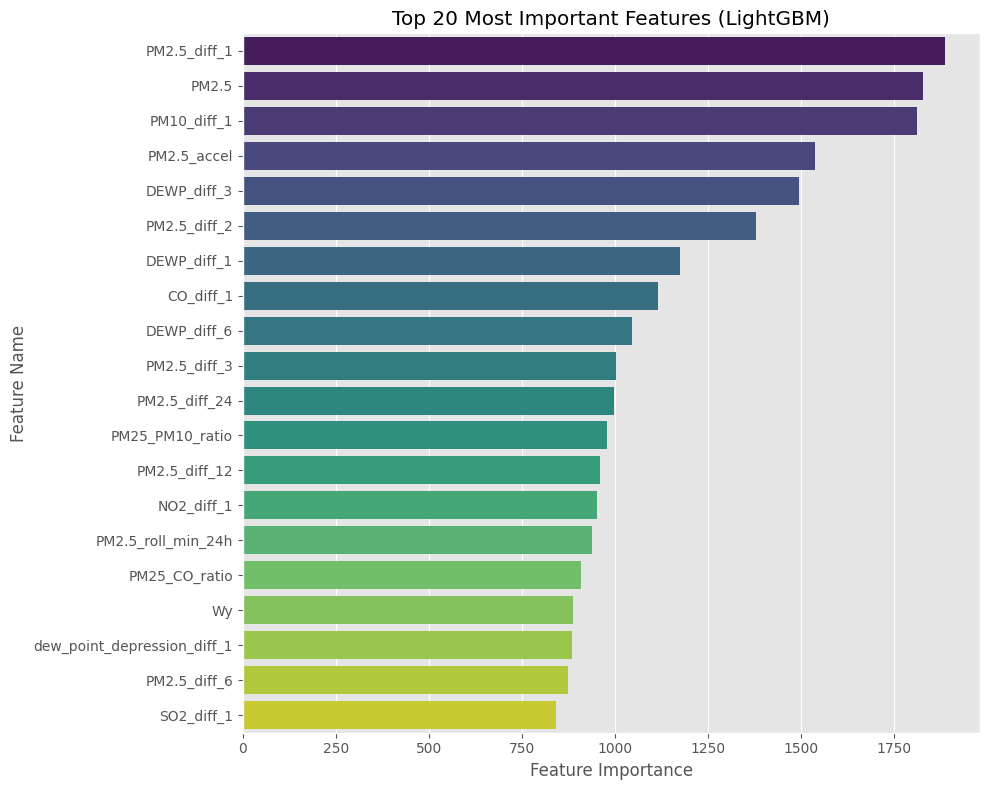

In [8]:
plt.figure(figsize=(10, 8))
imp_df = pd.DataFrame({'feature': feature_cols, 'importance': model_lgb.feature_importances_})
imp_df = imp_df.sort_values(by='importance', ascending=False).head(20)
sns.barplot(data=imp_df, x='importance', y='feature', palette='viridis')
plt.title('Top 20 Most Important Features (LightGBM)')
plt.xlabel('Feature Importance')
plt.ylabel('Feature Name')
plt.tight_layout()
plt.show()

### **Step 10: Generate Final Submission File**

In [9]:
sub_df = pd.DataFrame({
    'id': df_test['id'],
    'PM2.5': final_test_preds
})

sub_filename = 'submission_advanced_ensemble.csv'
sub_df.to_csv(sub_filename, index=False)
print(f"[SUCCESS] Saved {len(sub_df)} predictions to '{sub_filename}'")
display(sub_df.head(10))

# Automatically download on Colab
if 'google.colab' in sys.modules:
    from google.colab import files
    files.download(sub_filename)

[SUCCESS] Saved 4103 predictions to 'submission_advanced_ensemble.csv'


,id,PM2.5
0,test_00001,187.487410
1,test_00002,162.367979
2,test_00003,418.594240
3,test_00004,69.370141
4,test_00005,51.035246
5,test_00006,115.581847
6,test_00007,10.599359
7,test_00008,8.941975
8,test_00009,49.063504
9,test_00010,124.866568


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [12]:
import os
import joblib
import torch
import sys

# 1. Create directory to store final models
save_dir = 'final_trained_models'
os.makedirs(save_dir, exist_ok=True)

print("==================================================")
print(f" Saving All Final Models to '{save_dir}/'...")
print("==================================================")

# 2. Save LightGBM Model
model_lgb.booster_.save_model(os.path.join(save_dir, 'lightgbm_model.txt'))
print(" [✓] Saved LightGBM Model")

# 3. Save XGBoost Model
model_xgb.save_model(os.path.join(save_dir, 'xgboost_model.json'))
print(" [✓] Saved XGBoost Model")

# 4. Save CatBoost Model
model_cb.save_model(os.path.join(save_dir, 'catboost_model.cbm'))
print(" [✓] Saved CatBoost Model")

# 5. Save PyTorch Neural Network Weights
torch.save(net.state_dict(), os.path.join(save_dir, 'pytorch_nn_weights.pt'))
print(" [✓] Saved PyTorch Neural Net Weights")

# 6. Save Preprocessors & Metadata
joblib.dump(scaler, os.path.join(save_dir, 'scaler.pkl'))
joblib.dump(le_station, os.path.join(save_dir, 'label_encoder_station.pkl'))
joblib.dump(feature_cols, os.path.join(save_dir, 'feature_columns.pkl'))

ensemble_config = {
    'w_lgb': w_lgb,
    'w_xgb': w_xgb,
    'w_cb': w_cb,
    'w_nn': w_nn
}
joblib.dump(ensemble_config, os.path.join(save_dir, 'ensemble_weights.pkl'))
print(" [✓] Saved Scaler, Encoders, & Ensemble Weights")

print("\n[SUCCESS] All models & preprocessors successfully saved!")

# 7. Zip and Download automatically on Google Colab
if 'google.colab' in sys.modules:
    import shutil
    from google.colab import files

    zip_filename = 'final_trained_models.zip'
    shutil.make_archive('final_trained_models', 'zip', save_dir)
    print(f"\nZipping models to '{zip_filename}' and downloading...")
    files.download(zip_filename)


 Saving All Final Models to 'final_trained_models/'...
 [✓] Saved LightGBM Model
 [✓] Saved XGBoost Model
 [✓] Saved CatBoost Model
 [✓] Saved PyTorch Neural Net Weights
 [✓] Saved Scaler, Encoders, & Ensemble Weights

[SUCCESS] All models & preprocessors successfully saved!

Zipping models to 'final_trained_models.zip' and downloading...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>